Here we define and initialise the model using class. This is the more generalized way and it adds more functionality.

In [31]:
import numpy as np 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [32]:
#defining the classmodel 
class ANNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input=nn.Linear(2,10)
        self.output=nn.Linear(10 , 1)
    
    def forward(self , x):
        
        x=self.input(x)
        
        #x=F.relu(x)
        
        x=self.output(x)
        x=F.sigmoid(x)
        
        return x 
    
    
        

In [33]:
#making an instance of the class 
model=ANNmodel()

In [34]:
# defining the terms
learning_rate=0.01
lossfn=nn.BCELoss()
optimizer=torch.optim.Adam(model.parameters() , lr=learning_rate)

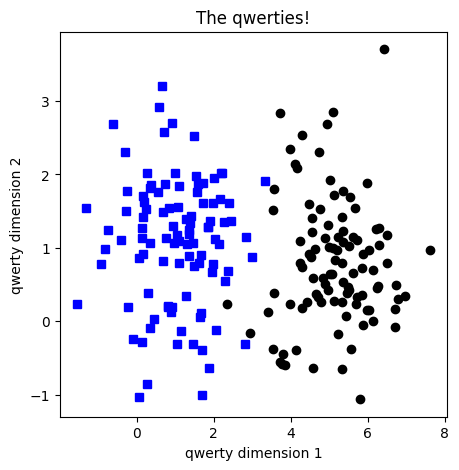

In [35]:
# create data

nPerClust = 100
blur = 1

A = [  1, 1 ]
B = [  5, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [36]:
# training the model

numepochs = 1000
losses = torch.zeros(numepochs)

for epochi in range(numepochs):

  # forward pass
  yHat = model(data)

  # compute loss
  loss = lossfn(yHat,labels)
  losses[epochi] = loss

  # backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

In [37]:
# compute the predictions

# manually compute losses
# final forward pass
predictions = model(data)

predlabels = predictions>.5

# find errors
misclassified = np.where(predlabels != labels)[0]

# total accuracy
totalacc = 100-100*len(misclassified)/(2*nPerClust)

print('Final accuracy: %g%%' %totalacc)


Final accuracy: 98.5%


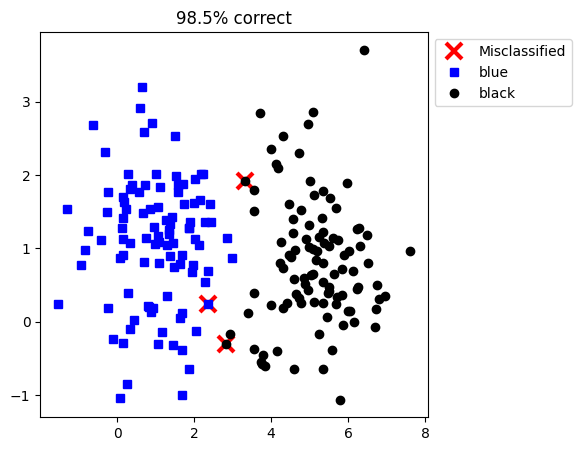

In [38]:
# plot the labeled data
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified,0] ,data[misclassified,1],'rx',markersize=12,markeredgewidth=3)
plt.plot(data[np.where(~predlabels)[0],0],data[np.where(~predlabels)[0],1],'bs')
plt.plot(data[np.where(predlabels)[0],0] ,data[np.where(predlabels)[0],1] ,'ko')

plt.legend(['Misclassified','blue','black'],bbox_to_anchor=(1,1))
plt.title(f'{totalacc}% correct')
plt.show()